[# ResOSc — Monte Carlo Parameter Optimization Demo

This notebook demonstrates `monte_carlo_optimize`, which searches the space of
system parameters **(masses, wall springs, coupling springs)** to find configurations
that jointly maximize two objectives:

| Objective | Metric |
|---|---|
| **Sensitivity** | Minimax worst-case sensitivity |
| **Frequency spread** | Relative bandwidth of the normal-mode spectrum |

### Strategy

Two-phase approach to keep runtime tractable:

**Phase 1 — Screening** (`n_samples` draws)  
Randomly sample parameter vectors and score each with a fast proxy:
$$\text{proxy} = \frac{1}{\sqrt{\sum_i 1/b_i^2}}, \qquad \text{spread} = \frac{\omega_\text{max} - \omega_\text{min}}{\bar\omega}$$
Combined score $= \alpha \cdot \widetilde{\text{proxy}} + (1-\alpha)\cdot \widetilde{\text{spread}}$. Metrics are normalized to $[0, 1]$. 
$\alpha \in [0,1]$ controls the strength of each metric in its contirbution to the score.

**Phase 2 — Refinement** (top `n_refine` candidates)  
Run the full minimax weight-vector optimization on shortlisted candidates, and extract the **Pareto front**.

The Pareto front collects every configuration where you cannot improve
sensitivity without sacrificing spread (and vice versa) — the efficient frontier.

## Imports

In [2]:
import os
import numpy as np                  
import matplotlib.pyplot as plt

from ResOSc import CoupledSystem                                                # type: ignore
from ResOSc.montecarlo import monte_carlo_optimize, plot_monte_carlo_results    # type: ignore

save_plots = 'figures-mc'

def fig_path(name):
    if save_plots is None:
        return None
    os.makedirs(save_plots, exist_ok=True)
    return os.path.join(save_plots, name)

---
## 1. Balanced Optimization (GW strain, equal weights)

Search for the system that best balances sensitivity and frequency spread
under GW-strain forcing.  `sensitivity_weight=0.5` treats both objectives equally.

In [3]:
result_gw = monte_carlo_optimize(
    n                  = 10,
    n_samples          = 5000,      # Phase 1: random draws
    n_refine           = 100,       # Phase 2: full optimization on top candidates
    gamma              = 0.01,
    force_model        = 'strain',  # GW tidal forcing
    wall_bounds        = (0.5, 3.0),
    coupling_bounds    = (0.01, 1.0),
    mass_bounds        = (0.3, 1.5),
    sensitivity_weight = 0.5,       # equal weight to both objectives
    spread_metric      = 'relative',
    seed               = 42,
    verbose            = True,
)

Phase 1: screening 5000 random configurations...
  Valid: 5000/5000
Phase 2: refining top 100 candidates with full minimax optimization...
  Refined 20/100...
  Refined 40/100...
  Refined 60/100...
  Refined 80/100...
  Refined 100/100...

Best configuration (combined score = 0.7262):
  Min sensitivity       : 6.0884
  Spread (relative)    : 1.8740
  Masses    : [0.306 1.312 1.075 1.096 1.486 1.305 0.616 1.318 1.093 1.382]
  Wall k    : [2.648 1.21  2.531 1.715 0.866 2.48  1.674 1.722 2.187 0.515]
  Coupling k: [0.949 0.273 0.682 0.129 0.824 0.131 0.091 0.758 0.124]
  Pareto-front size: 8


### 1a. Pareto scatter + best configuration sensitivity profile

In [2]:
plot_monte_carlo_results(result_gw, savefig=fig_path('mc_gw_balanced.pdf'))

NameError: name 'plot_monte_carlo_results' is not defined

### 1b. Best configuration — parameters and metrics

In [5]:
best = result_gw['top_combined']

print("=== Best combined-score configuration (GW strain, balanced) ===\n")
print(f"  Combined score              : {best['combined_score']:.4f}")
print(f"  Norm. min sensitivity       : {best['normalized_min_sensitivity']:.4f}")
print(f"  Relative frequency spread   : {best['spread_val']:.4f}")
print(f"  Reference scale             : {best['ref_scale']:.6f}")
print()
print(f"  Masses    : {np.round(best['masses'],   4)}")
print(f"  Wall k    : {np.round(best['wall'],     4)}")
print(f"  Coupling k: {np.round(best['coupling'], 4)}")
print()
print(f"  Normal frequencies: {np.round(best['system'].frequencies, 4)}")
print()
print(f"  Pareto-front size: {len(result_gw['pareto_front'])}")

=== Best combined-score configuration (GW strain, balanced) ===

  Combined score              : 0.7262
  Norm. min sensitivity       : 0.5251
  Relative frequency spread   : 1.8740
  Reference scale             : 11.593847

  Masses    : [0.3056 1.3118 1.0747 1.0958 1.4863 1.3045 0.6161 1.3184 1.0928 1.3816]
  Wall k    : [2.6484 1.2095 2.5307 1.7145 0.8658 2.4802 1.6736 1.7216 2.1874 0.515 ]
  Coupling k: [0.9492 0.2728 0.6825 0.1287 0.8242 0.1314 0.0915 0.7576 0.1238]

  Normal frequencies: [3.4632 1.8924 1.7861 1.7619 1.6691 1.4214 1.2697 1.2593 0.9994 0.6764]

  Pareto-front size: 8


### 1c. Pareto front — tabulated

Each row is a Pareto-optimal configuration: no other configuration dominates it
on **both** objectives simultaneously.

In [6]:
pareto = sorted(result_gw['pareto_front'], key=lambda r: r['spread_val'])

print(f"{'#':<4} {'Norm. sensitivity':>20} {'Rel. spread':>14} {'Combined score':>16}")
print('─' * 58)
for i, r in enumerate(pareto):
    ns = r.get('normalized_min_sensitivity') or r['min_sensitivity']
    print(f"{i:<4} {ns:>20.4f} {r['spread_val']:>14.4f} {r['combined_score']:>16.4f}")

#       Norm. sensitivity    Rel. spread   Combined score
──────────────────────────────────────────────────────────
0                  0.8422         1.0258           0.5461
1                  0.5993         1.2255           0.5837
2                  0.7198         1.4145           0.5801
3                  0.6407         1.4727           0.5438
4                  0.4593         1.6072           0.5998
5                  0.5962         1.6228           0.5955
6                  0.5251         1.8740           0.7262
7                  0.3260         1.8813           0.5871


---
## 2. Sensitivity-First vs Spread-First

By changing `sensitivity_weight` we can bias the search toward one objective.
Here we compare three operating points on the trade-off curve:

| Run | `sensitivity_weight` | Priority |
|---|---|---|
| A | 0.9 | Maximize sensitivity, spread secondary |
| B | 0.5 | Balanced (same as Section 1) |
| C | 0.1 | Maximize spread, sensitivity secondary |

In [9]:
common = dict(
    n=10, n_samples=5000, n_refine=100,
    gamma=0.01, force_model='strain',
    wall_bounds=(0.5, 3.0), coupling_bounds=(0.01, 1.0), mass_bounds=(0.3, 1.5),
    spread_metric='relative', seed=42, verbose=False,
)

result_sens_first   = monte_carlo_optimize(**common, sensitivity_weight=0.9)
result_spread_first = monte_carlo_optimize(**common, sensitivity_weight=0.1)

runs = [
    ('Sensitivity-first (α=0.9)', result_sens_first),
    ('Balanced           (α=0.5)', result_gw),
    ('Spread-first       (α=0.1)', result_spread_first),
]

print(f"{'Run':<32} {'Norm. sensitivity':>20} {'Rel. spread':>14}")
print('─' * 68)
for label, res in runs:
    b = res['top_combined']
    ns = b.get('normalized_min_sensitivity') or b['min_sensitivity']
    print(f"  {label:<30} {ns:>20.4f} {b['spread_val']:>14.4f}")

Run                                 Norm. sensitivity    Rel. spread
────────────────────────────────────────────────────────────────────
  Sensitivity-first (α=0.9)                    0.8422         1.0258
  Balanced           (α=0.5)                   0.5251         1.8740
  Spread-first       (α=0.1)                   0.5251         1.8740


### 2a. Side-by-side sensitivity profiles

Compare the per-mode sensitivity profile of the three best configurations.

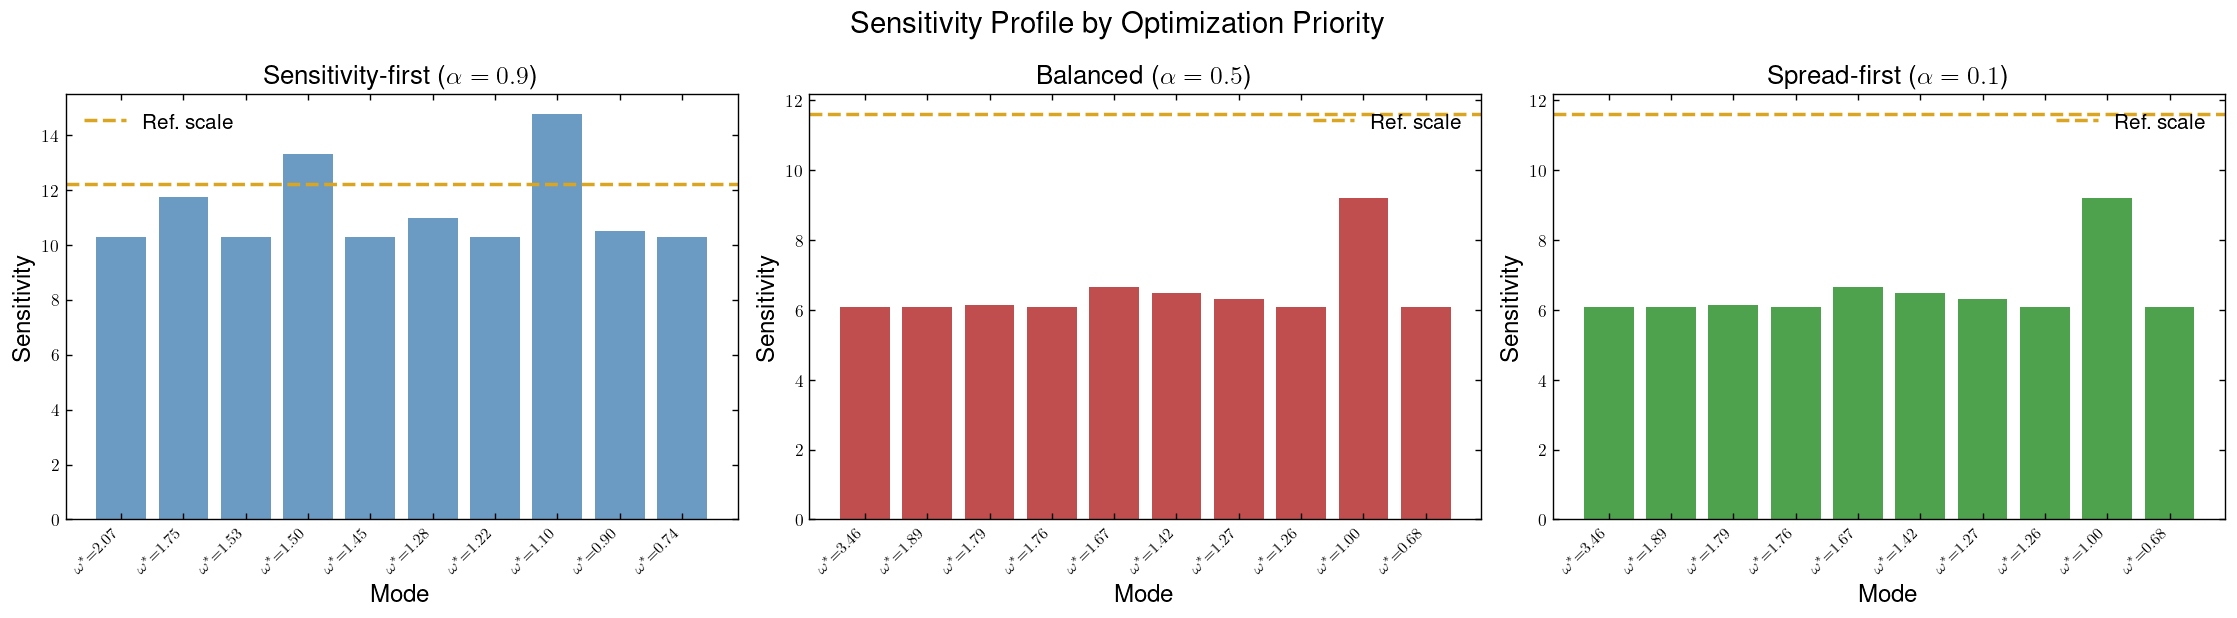

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=125, sharey=False)
colors = ['steelblue', 'firebrick', 'forestgreen']
titles = [r'Sensitivity-first ($\alpha=0.9$)',
          r'Balanced ($\alpha=0.5$)',
          r'Spread-first ($\alpha=0.1$)']

for ax, (label, res), color, title in zip(axes, runs, colors, titles):
    b    = res['top_combined']
    n    = b['system'].n
    freqs = b['system'].frequencies
    x_pos = np.arange(n)

    ax.bar(x_pos, b['sensitivities'], color=color, alpha=0.8)
    if b.get('ref_scale'):
        ax.axhline(b['ref_scale'], color='goldenrod', linewidth=2,
                   linestyle='--', label=r'Ref.\ scale')
        ax.legend(frameon=False, fontsize=12)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r'Mode', fontsize=14)
    ax.set_ylabel(r'Sensitivity', fontsize=14)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([fr'$\omega^*\!\!=\!\!{freqs[i]:.2f}$' for i in range(n)],
                       fontsize=9, rotation=45, ha='right')
    ax.tick_params(direction='in', top=True, right=True)

plt.suptitle(r'Sensitivity Profile by Optimization Priority', fontsize=17)
plt.tight_layout()
fig.savefig(fig_path('mc_priority_comparison.pdf'), format='pdf',
            bbox_inches='tight', pad_inches=0.10)
plt.show()

---
## 3. DM Uniform Force Model

Repeat the balanced search under dark-matter uniform momentum-impulse forcing
to see how the optimal parameter region shifts.

In [16]:
result_dm = monte_carlo_optimize(
    n                  = 10,
    n_samples          = 5000,
    n_refine           = 100,
    gamma              = 0.01,
    force_model        = 'uniform',  # DM momentum impulse
    wall_bounds        = (0.5, 3.0),
    coupling_bounds    = (0.01, 1.0),
    mass_bounds        = (0.3, 1.5),
    sensitivity_weight = 0.5,
    spread_metric      = 'relative',
    seed               = 42,
    verbose            = True,
)

plot_monte_carlo_results(result_dm, savefig=fig_path('mc_dm_balanced.pdf'))

Phase 1: screening 5000 random configurations...
  Valid: 5000/5000
Phase 2: refining top 100 candidates with full minimax optimization...


KeyboardInterrupt: 

### 3a. Cross-model comparison of best configurations

In [12]:
model_runs = [
    ('GW Strain',   result_gw),
    ('DM Uniform',  result_dm),
]

print(f"{'Force model':<16} {'Norm. sensitivity':>20} {'Rel. spread':>14} {'Pareto size':>13}")
print('─' * 65)
for label, res in model_runs:
    b  = res['top_combined']
    ns = b.get('normalized_min_sensitivity') or b['min_sensitivity']
    print(f"  {label:<14} {ns:>20.4f} {b['spread_val']:>14.4f} {len(res['pareto_front']):>13}")

Force model         Norm. sensitivity    Rel. spread   Pareto size
─────────────────────────────────────────────────────────────────
  GW Strain                    0.5251         1.8740             8
  DM Uniform                   0.4283         1.8559            19


---
## 4. Inspecting the Raw Screening Cloud

The `screening_scores` array holds the Phase 1 proxy values for every valid draw.
Plotting this cloud shows the full shape of the objective landscape before refinement.

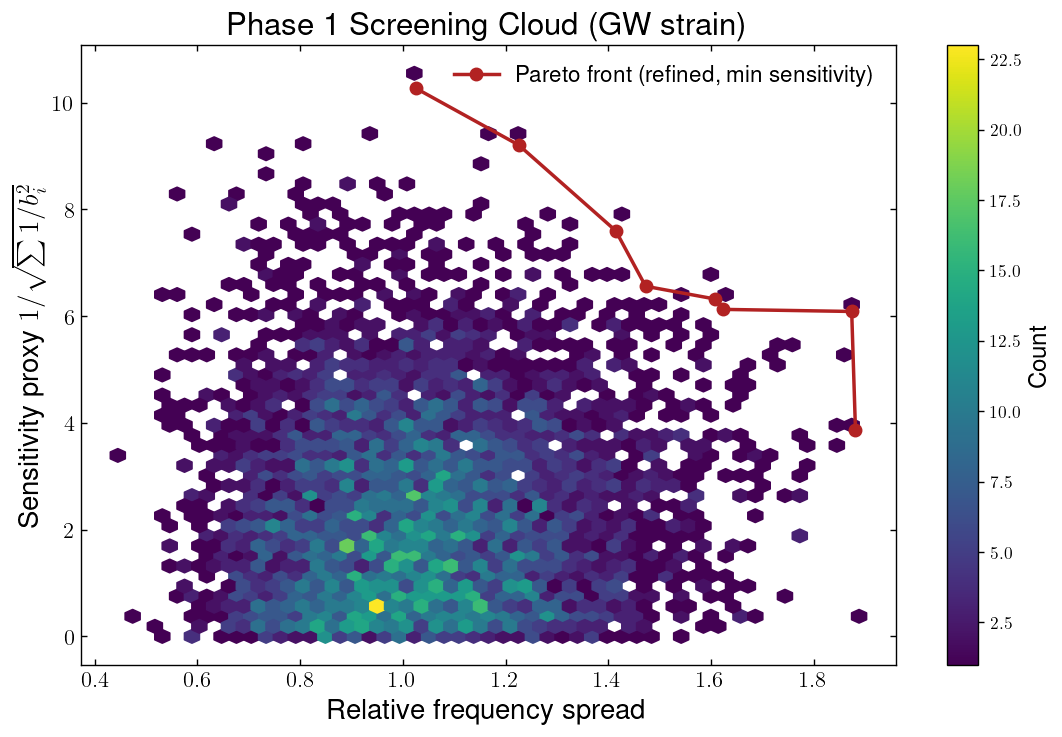

Screening cloud: 5000 valid draws out of 5000
Proxy range   : [0.0008, 10.5500]
Spread range  : [0.4448, 1.8884]


In [15]:
sc = result_gw['screening_scores']   # shape (n_valid, 2): [proxy, spread]

fig, ax = plt.subplots(figsize=(9, 6), dpi=125)
h = ax.hexbin(sc[:, 1], sc[:, 0], gridsize=50, cmap='viridis', mincnt=1)
cb = fig.colorbar(h, ax=ax)
cb.set_label(r'Count', fontsize=14)

# Overlay the Pareto front — use min_sensitivity (raw) so it sits on the
# same scale as the proxy cloud (both are unnormalized sensitivity values)
pareto = sorted(result_gw['pareto_front'], key=lambda r: r['spread_val'])
px = [r['spread_val']      for r in pareto]
py = [r['min_sensitivity'] for r in pareto]
ax.plot(px, py, 'o-', color='firebrick', linewidth=2, markersize=7,
        label=r'Pareto front (refined, min sensitivity)')

ax.set_xlabel(r'Relative frequency spread', fontsize=16)
ax.set_ylabel(r'Sensitivity proxy  $1/\sqrt{\sum 1/b_i^2}$', fontsize=16)
ax.set_title(r'Phase 1 Screening Cloud (GW strain)', fontsize=18)
ax.tick_params(direction='in', top=True, right=True, labelsize=13)
ax.legend(frameon=False, fontsize=13)
plt.tight_layout()
fig.savefig(fig_path('mc_screening_cloud.pdf'), format='pdf',
            bbox_inches='tight', pad_inches=0.10)
plt.show()

print(f"Screening cloud: {len(sc)} valid draws out of 5000")
print(f"Proxy range   : [{sc[:,0].min():.4f}, {sc[:,0].max():.4f}]")
print(f"Spread range  : [{sc[:,1].min():.4f}, {sc[:,1].max():.4f}]")

---
## 5. Reconstructing a Best System

Once you have the optimal parameters, you can reconstruct the `CoupledSystem`
object directly and use the full ResOSc API on it.

Optimal system frequencies: [3.4632 1.8924 1.7861 1.7619 1.6691 1.4214 1.2697 1.2593 0.9994 0.6764]
Frequency spread (relative): 1.874



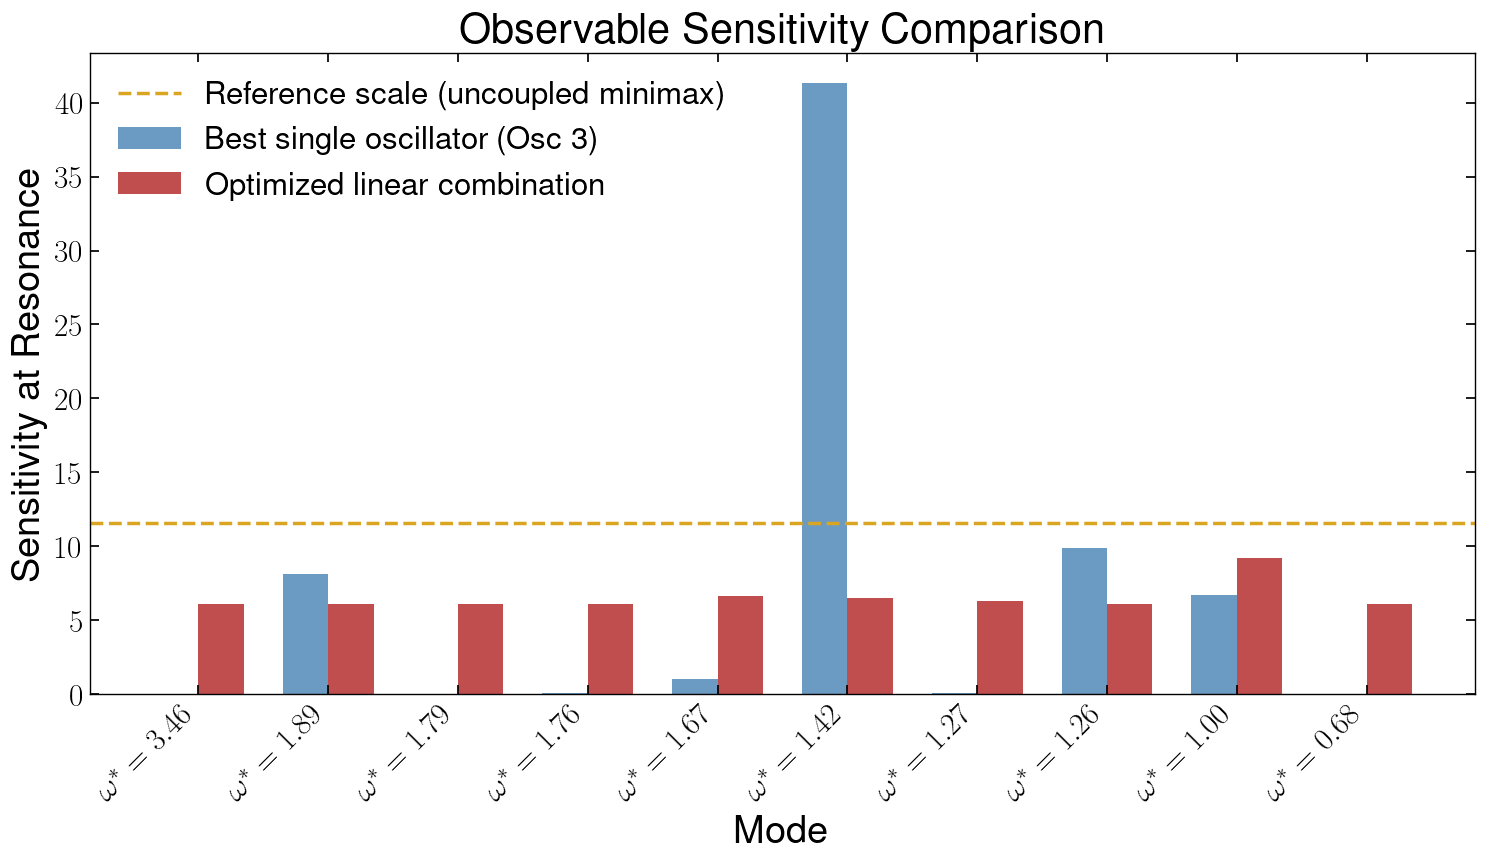

{'best_single_oscillator': 3,
 'best_single_sensitivities': array([4.19623235e-03, 8.13499916e+00, 2.13147387e-02, 5.16932208e-02,
        1.03109366e+00, 4.13148072e+01, 4.77618590e-02, 9.85465105e+00,
        6.69306389e+00, 1.96924895e-04]),
 'optimal_weights': array([ 0.71092874,  0.04301637, -0.2104818 ,  0.29698525,  0.03764599,
         0.14228637,  0.04119681,  0.17324193, -0.54360289,  0.1065383 ]),
 'optimal_sensitivities': array([6.08838792, 6.08838813, 6.12192013, 6.08838792, 6.65538018,
        6.48813607, 6.30501172, 6.08838793, 9.19561235, 6.09218523]),
 'ref_scale': np.float64(11.593847114019297),
 'normalized_best_single_min': np.float64(1.6985293413764633e-05),
 'normalized_optimal_min_sensitivity': np.float64(0.5251395731190894)}

In [14]:
from ResOSc.observables import compare_observables  # type: ignore

best = result_gw['top_combined']

# The solved system and its reference are already stored in the result dict —
# no need to rebuild.  But you can always reconstruct from the parameter arrays:
sys_best = best['system']
ref_best = best['reference']

print("Optimal system frequencies:", np.round(sys_best.frequencies, 4))
print("Frequency spread (relative):", round(best['spread_val'], 4))
print()

# Full sensitivity comparison plot using the existing API
compare_observables(sys_best, reference=ref_best,
                    savefig=fig_path('mc_best_observable.pdf'))